<a href="https://colab.research.google.com/github/Maheshwar-ap/Deep-Learning-/blob/main/DL_exp7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading model...


config.json:   0%|          | 0.00/4.61k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  982MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/445 [00:00<?, ?it/s]

...

special_tokens_map.json:   0%|          | 0.00/120 [00:00<?, ?B/s]

Model loaded successfully!
Using device: cpu

Please upload an image:


Saving happy-pet-dogs-playing-park_1359-281.avif to happy-pet-dogs-playing-park_1359-281.avif
Image uploaded: happy-pet-dogs-playing-park_1359-281.avif


[transformers] We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.



Input Image:


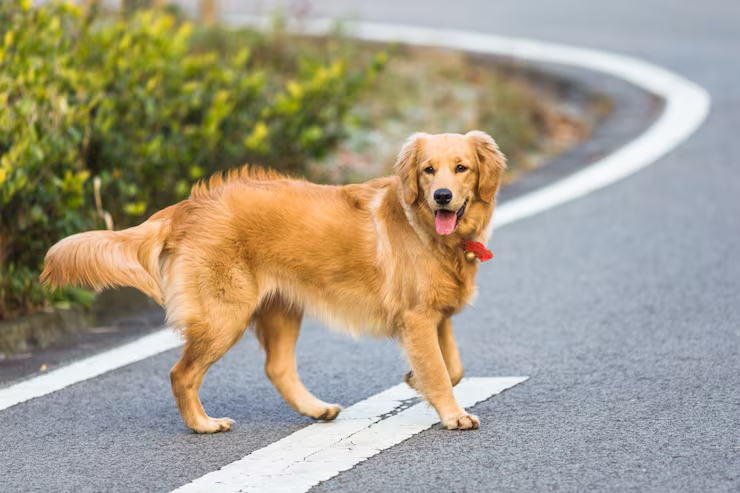


Generated Caption:
a brown dog standing on the side of a road 


In [1]:
# ============================================
# IMAGE CAPTIONING USING ViT-GPT2
# Google Colab
# ============================================

# Step 1: Install required libraries
!pip install -q transformers torch pillow

# Step 2: Import libraries
import torch
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer
from PIL import Image
from google.colab import files
from IPython.display import display


# Step 3: Load pretrained image captioning model
model_name = "nlpconnect/vit-gpt2-image-captioning"

print("Loading model...")

model = VisionEncoderDecoderModel.from_pretrained(model_name)

processor = ViTImageProcessor.from_pretrained(model_name)

tokenizer = AutoTokenizer.from_pretrained(model_name)


# Step 4: Select device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model.to(device)
model.eval()

print("Model loaded successfully!")
print("Using device:", device)


# Step 5: Define caption generation function
def generate_caption(image_path, max_length=30, num_beams=4):

    # Open image
    image = Image.open(image_path).convert("RGB")

    # Convert image into model input
    pixel_values = processor(
        images=image,
        return_tensors="pt"
    ).pixel_values.to(device)

    # Generate caption
    output_ids = model.generate(
        pixel_values,
        max_length=max_length,
        num_beams=num_beams,
        early_stopping=True
    )

    # Convert output tokens into text
    caption = tokenizer.decode(
        output_ids[0],
        skip_special_tokens=True
    )

    return caption


# Step 6: Upload image
print("\nPlease upload an image:")

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

print("Image uploaded:", image_path)


# Step 7: Generate caption
caption = generate_caption(image_path)


# Step 8: Display image
print("\nInput Image:")
display(Image.open(image_path))


# Step 9: Display generated caption
print("\nGenerated Caption:")
print(caption)